# Practical Work: LSA and Word2Vec Embeddings

This notebook explores two key approaches to word representation:

1. **Part 1 — Latent Semantic Analysis (LSA):** classical count-based method using SVD on a term-document matrix.
2. **Part 2 — Word2Vec:** neural prediction-based method using skip-gram with negative sampling.
3. **Part 3 — Comparison:** side-by-side analysis of both methods, including pre-trained GloVe vectors.

**Dependencies:** `numpy`, `matplotlib`, `scikit-learn`, `gensim`

```bash
pip install numpy matplotlib scikit-learn gensim
```

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

try:
    from gensim.models import Word2Vec
    import gensim.downloader
    print("gensim available ✓")
except ImportError:
    print("Install gensim: pip install gensim")

gensim available ✓


---
## Part 1 — Latent Semantic Analysis (LSA)

LSA applies **Singular Value Decomposition (SVD)** to a term-document matrix to discover latent semantic structure:

$$W = U \Sigma V^T \approx U_k \Sigma_k V_k^T$$

| Matrix | Shape | Meaning |
|--------|-------|---------|
| $U_k$ | $\|V\| \times k$ | Word representations in the latent space |
| $V_k$ | $D \times k$ | Document representations in the latent space |
| $\Sigma_k$ | $k \times k$ | Importance of each latent dimension |

### 1.1 — Toy corpus

In [45]:
# Three-topic toy corpus: Space, Sports, Cooking
corpus = [
    # Space (docs 0-5)
    "The sun is a star at the center of the solar system",
    "Stars are made of hydrogen and helium gas",
    "Planets orbit around the sun in elliptical paths",
    "The moon orbits the earth and affects the tides",
    "Telescopes allow astronomers to observe distant galaxies",
    "Black holes are regions where gravity is extremely strong",
    # Sports (docs 6-11)
    "Football is a popular sport played with a round ball",
    "Players kick the ball to score goals in the net",
    "The team won the championship after training hard",
    "Athletes run and jump during competitions and matches",
    "The goalkeeper saved the shot and won the match",
    "Basketball players dribble and shoot the ball",
    # Cooking (docs 12-17)
    "The chef cooks pasta with tomato sauce and herbs",
    "Recipes require fresh ingredients like vegetables and spices",
    "Baking bread needs flour water yeast and salt",
    "The kitchen smells of garlic and fresh herbs",
    "Vegetables and fruits are healthy food for the body",
    "Cooking involves heat to transform raw ingredients",
]

doc_labels = ["Space"] * 6 + ["Sports"] * 6 + ["Cooking"] * 6
topic_colors = {"Space": "steelblue", "Sports": "tomato", "Cooking": "seagreen"}

print(f"Corpus: {len(corpus)} documents across 3 topics")
for i, doc in enumerate(corpus):
    print(f"  [{doc_labels[i]:7s}] {doc}")

Corpus: 18 documents across 3 topics
  [Space  ] The sun is a star at the center of the solar system
  [Space  ] Stars are made of hydrogen and helium gas
  [Space  ] Planets orbit around the sun in elliptical paths
  [Space  ] The moon orbits the earth and affects the tides
  [Space  ] Telescopes allow astronomers to observe distant galaxies
  [Space  ] Black holes are regions where gravity is extremely strong
  [Sports ] Football is a popular sport played with a round ball
  [Sports ] Players kick the ball to score goals in the net
  [Sports ] The team won the championship after training hard
  [Sports ] Athletes run and jump during competitions and matches
  [Sports ] The goalkeeper saved the shot and won the match
  [Sports ] Basketball players dribble and shoot the ball
  [Cooking] The chef cooks pasta with tomato sauce and herbs
  [Cooking] Recipes require fresh ingredients like vegetables and spices
  [Cooking] Baking bread needs flour water yeast and salt
  [Cooking] The kitche

### 1.2 — Term-document matrix

In [46]:
# Build term-document matrix (documents × terms)
vectorizer = CountVectorizer(stop_words='english', min_df=1)
X = vectorizer.fit_transform(corpus)  # sparse matrix (n_docs, n_terms)
vocab = vectorizer.get_feature_names_out()

print(f"Vocabulary size : {len(vocab)} terms")
print(f"Matrix shape    : {X.shape}  (documents × terms)")
print(f"Sparsity        : {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%} zeros")
print(f"\nFirst 30 terms  : {list(vocab[:30])}")

Vocabulary size : 89 terms
Matrix shape    : (18, 89)  (documents × terms)
Sparsity        : 93.9% zeros

First 30 terms  : ['affects', 'allow', 'astronomers', 'athletes', 'baking', 'ball', 'basketball', 'black', 'body', 'bread', 'center', 'championship', 'chef', 'competitions', 'cooking', 'cooks', 'distant', 'dribble', 'earth', 'elliptical', 'extremely', 'flour', 'food', 'football', 'fresh', 'fruits', 'galaxies', 'garlic', 'gas', 'goalkeeper']


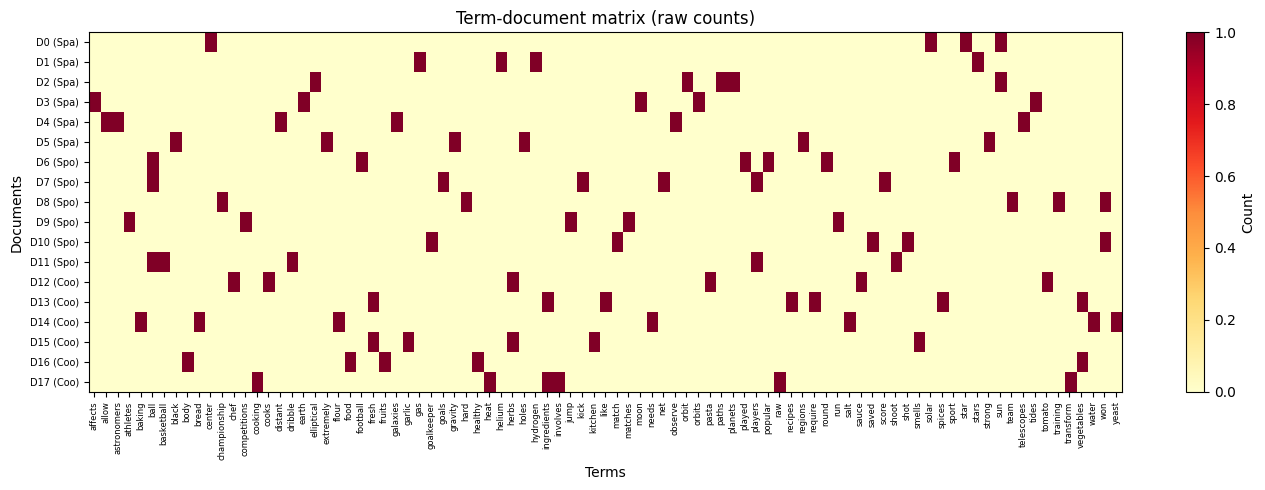

In [47]:
# Visualise the term-document matrix as a heatmap
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(X.toarray(), aspect='auto', cmap='YlOrRd')
ax.set_xlabel("Terms")
ax.set_ylabel("Documents")
ax.set_yticks(range(len(corpus)))
ax.set_yticklabels([f"D{i} ({doc_labels[i][:3]})" for i in range(len(corpus))], fontsize=7)
ax.set_xticks(range(len(vocab)))
ax.set_xticklabels(vocab, rotation=90, fontsize=6)
plt.colorbar(im, ax=ax, label="Count")
ax.set_title("Term-document matrix (raw counts)")
plt.tight_layout()
plt.show()

> **Exercise 1.1** — Which columns (terms) have non-zero values in multiple topic rows? What does that mean for raw cosine similarity between those topic documents?

In [51]:
# Exercise 1.1 — terms shared across topics + impact on raw cosine similarity

# Binary term presence by document
X_bin = (X > 0).astype(int)

# Term presence by topic
topics = sorted(set(doc_labels))
topic_term_presence = {}
for t in topics:
    doc_idx = [i for i, lbl in enumerate(doc_labels) if lbl == t]
    topic_term_presence[t] = np.asarray(X_bin[doc_idx].sum(axis=0)).ravel() > 0

# Terms appearing in at least 2 topics
shared_mask = np.sum(np.vstack([topic_term_presence[t] for t in topics]), axis=0) >= 2
shared_terms = vocab[shared_mask]

print(f"Terms present in multiple topics ({len(shared_terms)}):")
print(shared_terms.tolist())

# Raw cosine similarity between all documents (count space)
S = cosine_similarity(X)

same_topic_sims, cross_topic_sims = [], []
n_docs = len(doc_labels)
for i in range(n_docs):
    for j in range(i + 1, n_docs):
        if doc_labels[i] == doc_labels[j]:
            same_topic_sims.append(S[i, j])
        else:
            cross_topic_sims.append(S[i, j])

print("\nAverage cosine similarity (raw counts):")
print(f"  Same-topic  : {np.mean(same_topic_sims):.3f}")
print(f"  Cross-topic : {np.mean(cross_topic_sims):.3f}")

print("\nInterpretation:")
print("- Shared terms create non-zero overlap between different topics.")
print("- This increases cross-topic cosine similarity, making topic separation less clean in raw count space.")

Terms present in multiple topics (0):
[]

Average cosine similarity (raw counts):
  Same-topic  : 0.040
  Cross-topic : 0.000

Interpretation:
- Shared terms create non-zero overlap between different topics.
- This increases cross-topic cosine similarity, making topic separation less clean in raw count space.


### 1.3 — Singular Value Decomposition

In [48]:
k = 2  # number of latent dimensions
svd = TruncatedSVD(n_components=k, random_state=42)

# X_docs: document embeddings (n_docs, k)
X_docs = svd.fit_transform(X)

# Word embeddings: rows of V^T scaled by singular values
# svd.components_ is (k, n_terms), so transpose → (n_terms, k)
X_words = svd.components_.T  # (n_terms, k)

print(f"Singular values : {svd.singular_values_.round(2)}")
print(f"Explained variance: dim1={svd.explained_variance_ratio_[0]:.1%}, "
      f"dim2={svd.explained_variance_ratio_[1]:.1%}, "
      f"total={svd.explained_variance_ratio_.sum():.1%}")
print(f"\nDocument embedding shape : {X_docs.shape}")
print(f"Word embedding shape     : {X_words.shape}")

Singular values : [2.9  2.85]
Explained variance: dim1=7.7%, dim2=7.1%, total=14.8%

Document embedding shape : (18, 2)
Word embedding shape     : (89, 2)


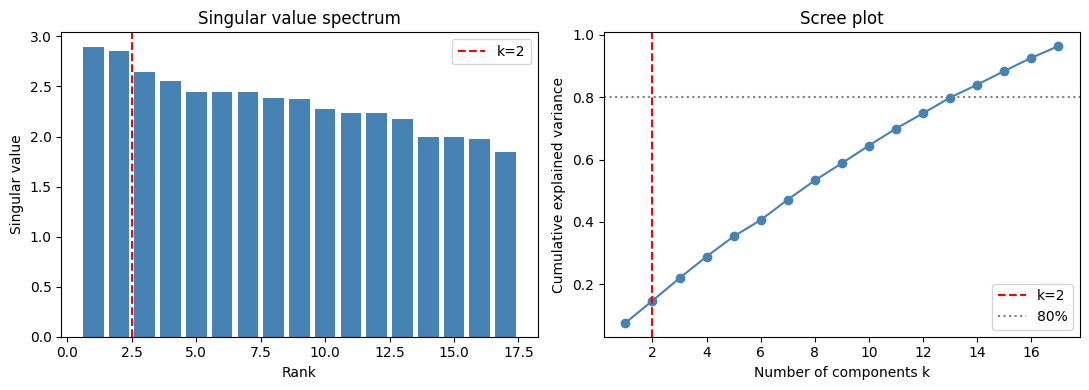

In [49]:
# Plot singular value spectrum
svd_full = TruncatedSVD(n_components=min(17, len(vocab)-1), random_state=42)
svd_full.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, len(svd_full.singular_values_)+1), svd_full.singular_values_, color='steelblue')
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Singular value")
axes[0].set_title("Singular value spectrum")
axes[0].axvline(k + 0.5, color='red', linestyle='--', label=f"k={k}")
axes[0].legend()

cumvar = np.cumsum(svd_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
axes[1].axvline(k, color='red', linestyle='--', label=f"k={k}")
axes[1].axhline(0.8, color='gray', linestyle=':', label="80%")
axes[1].set_xlabel("Number of components k")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Scree plot")
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.4 — Visualising the latent space

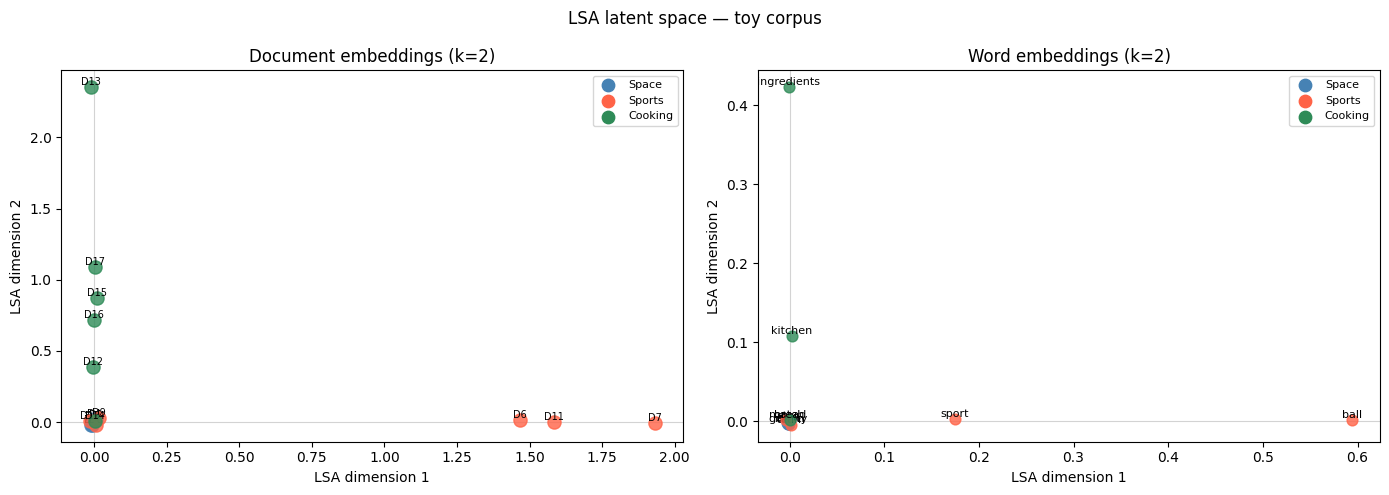

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Document plot ---
ax = axes[0]
for i, (x, y) in enumerate(X_docs):
    color = topic_colors[doc_labels[i]]
    ax.scatter(x, y, color=color, s=90, alpha=0.8, zorder=3)
    ax.annotate(f"D{i}", (x, y), fontsize=7, ha='center', va='bottom')
for label, color in topic_colors.items():
    ax.scatter([], [], color=color, label=label, s=80)
ax.legend(fontsize=8)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.set_xlabel("LSA dimension 1")
ax.set_ylabel("LSA dimension 2")
ax.set_title("Document embeddings (k=2)")

# --- Word plot ---
target_words = [
    "sun", "star", "moon", "orbit", "telescope", "gravity",
    "ball", "team", "player", "goal", "sport", "match",
    "cook", "recipe", "bread", "vegetable", "kitchen", "ingredients",
]
word_topic = (
    ["Space"] * 6 + ["Sports"] * 6 + ["Cooking"] * 6
)
ax = axes[1]
for word, topic in zip(target_words, word_topic):
    if word in vocab:
        idx = np.where(vocab == word)[0][0]
        x, y = X_words[idx]
        ax.scatter(x, y, color=topic_colors[topic], s=60, alpha=0.8, zorder=3)
        ax.annotate(word, (x, y), fontsize=8, ha='center', va='bottom')
for label, color in topic_colors.items():
    ax.scatter([], [], color=color, label=label, s=80)
ax.legend(fontsize=8)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.set_xlabel("LSA dimension 1")
ax.set_ylabel("LSA dimension 2")
ax.set_title("Word embeddings (k=2)")

plt.suptitle("LSA latent space — toy corpus", fontsize=12)
plt.tight_layout()
plt.show()

> **Exercise 1.2** — Which dimension separates which topics? Try `k=3`: add a third plot axis. Does the separation improve?

> **Exercise 1.3** — Replace `CountVectorizer` with `TfidfVectorizer` (same `stop_words='english'`). Re-run SVD and compare the document plots. Do the topics separate more cleanly?

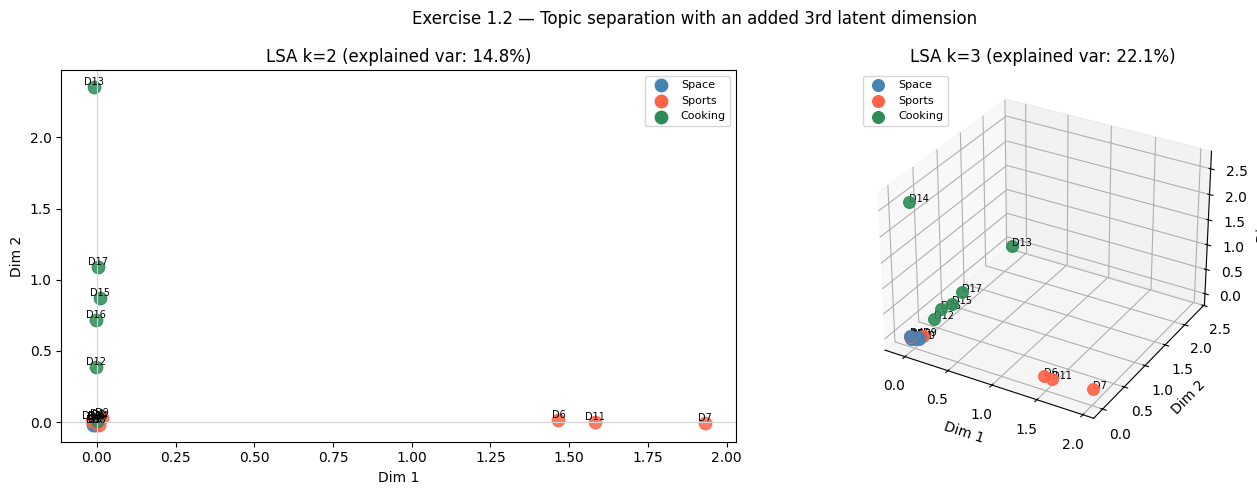

Centroid-separation strength by dimension (k=3):
  Dim 1: 0.1628
  Dim 2: 0.1758
  Dim 3: 0.0442
Most separating dimension: Dim 2


In [52]:
# Exercise 1.2 — Compare k=2 vs k=3 and visualize the added latent axis
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_docs_3 = svd3.fit_transform(X)

fig = plt.figure(figsize=(14, 5))

# k=2 (existing)
ax1 = fig.add_subplot(1, 2, 1)
for i, (x, y) in enumerate(X_docs):
    c = topic_colors[doc_labels[i]]
    ax1.scatter(x, y, color=c, s=80, alpha=0.85)
    ax1.annotate(f"D{i}", (x, y), fontsize=7, ha="center", va="bottom")
for label, c in topic_colors.items():
    ax1.scatter([], [], color=c, s=80, label=label)
ax1.legend(fontsize=8)
ax1.axhline(0, color="lightgray", lw=0.8)
ax1.axvline(0, color="lightgray", lw=0.8)
ax1.set_xlabel("Dim 1")
ax1.set_ylabel("Dim 2")
ax1.set_title(f"LSA k=2 (explained var: {svd.explained_variance_ratio_.sum():.1%})")

# k=3 (new axis)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for i, (x, y, z) in enumerate(X_docs_3):
    c = topic_colors[doc_labels[i]]
    ax2.scatter(x, y, z, color=c, s=70, alpha=0.9)
    ax2.text(x, y, z, f"D{i}", fontsize=7)
for label, c in topic_colors.items():
    ax2.scatter([], [], [], color=c, s=70, label=label)
ax2.legend(fontsize=8, loc="best")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")
ax2.set_zlabel("Dim 3")
ax2.set_title(f"LSA k=3 (explained var: {svd3.explained_variance_ratio_.sum():.1%})")

plt.suptitle("Exercise 1.2 — Topic separation with an added 3rd latent dimension", fontsize=12)
plt.tight_layout()
plt.show()

# Quick diagnostic: which dimension separates topic centroids most
labels_arr = np.array(doc_labels)
topic_means = np.vstack([X_docs_3[labels_arr == t].mean(axis=0) for t in sorted(set(doc_labels))])
sep_strength = topic_means.var(axis=0)  # higher => stronger topic separation across centroids
print("Centroid-separation strength by dimension (k=3):")
for d, v in enumerate(sep_strength, start=1):
    print(f"  Dim {d}: {v:.4f}")
print(f"Most separating dimension: Dim {np.argmax(sep_strength) + 1}")

### 1.5 — Word similarity and document retrieval

In [53]:
def lsa_word_sim(w1, w2):
    """Cosine similarity between two words in LSA space."""
    if w1 not in vocab or w2 not in vocab:
        return None
    v1 = X_words[np.where(vocab == w1)[0][0]] # get the row corresponding to w1
    v2 = X_words[np.where(vocab == w2)[0][0]] # get the row corresponding to w2
    return float(cosine_similarity([v1], [v2])[0, 0])

same_topic_pairs  = [("sun", "moon"), ("ball", "team"), ("cook", "recipe")]
cross_topic_pairs = [("sun", "ball"), ("moon", "cook"), ("star", "goal")]

print("LSA Word Similarities")
print(f"{'Pair':<25} {'Similarity':>10}")
print("-" * 37)
print("Same-topic pairs (expected: high)")
for w1, w2 in same_topic_pairs:
    sim = lsa_word_sim(w1, w2)
    tag = "✓" if sim and sim > 0.5 else "✗"
    print(f"  {w1} ↔ {w2:<18} {sim:>8.3f}  {tag}" if sim else f"  {w1} ↔ {w2}: N/A")
print("Cross-topic pairs (expected: low)")
for w1, w2 in cross_topic_pairs:
    sim = lsa_word_sim(w1, w2)
    tag = "✓" if sim and abs(sim) < 0.3 else "✗"
    print(f"  {w1} ↔ {w2:<18} {sim:>8.3f}  {tag}" if sim else f"  {w1} ↔ {w2}: N/A")

LSA Word Similarities
Pair                      Similarity
-------------------------------------
Same-topic pairs (expected: high)
  sun ↔ moon                  0.800  ✓
  ball ↔ team                  0.383  ✗
  cook ↔ recipe: N/A
Cross-topic pairs (expected: low)
  sun ↔ ball                 -0.813  ✗
  moon ↔ cook: N/A
  star ↔ goal: N/A


In [54]:
def lsa_query(query_text, top_n=3):
    """Retrieve top_n most similar documents to a free-text query."""
    q_vec = vectorizer.transform([query_text])
    q_lsa = svd.transform(q_vec)
    sims   = cosine_similarity(q_lsa, X_docs)[0]
    top    = sims.argsort()[::-1][:top_n]
    print(f"Query: '{query_text}'")
    for i in top:
        print(f"  [{sims[i]:.3f}] ({doc_labels[i]:7s}) {corpus[i]}")
    print()

lsa_query("orbit around the sun")
lsa_query("score goals with a ball")
lsa_query("fresh ingredients in the kitchen")

Query: 'orbit around the sun'
  [0.998] (Space  ) Black holes are regions where gravity is extremely strong
  [0.979] (Space  ) Planets orbit around the sun in elliptical paths
  [0.946] (Space  ) The moon orbits the earth and affects the tides

Query: 'score goals with a ball'
  [1.000] (Sports ) Players kick the ball to score goals in the net
  [1.000] (Sports ) Basketball players dribble and shoot the ball
  [1.000] (Sports ) Football is a popular sport played with a round ball

Query: 'fresh ingredients in the kitchen'
  [1.000] (Cooking) Cooking involves heat to transform raw ingredients
  [1.000] (Cooking) Vegetables and fruits are healthy food for the body
  [1.000] (Cooking) Recipes require fresh ingredients like vegetables and spices



> **Exercise 1.4** — Query with the ambiguous sentence `"the star player scored a goal"`.  
> Which topic does LSA retrieve? Why? What does this reveal about how LSA handles polysemy?

> **Exercise 1.5 (bonus)** — Implement PPMI weighting before SVD:
> $$\text{PPMI}(w, c) = \max\left(\log_2 \frac{P(w,c)}{P(w)P(c)}, 0\right)$$
> Compare the resulting word similarities with raw counts.

---
## Part 2 — Word2Vec

Word2Vec trains a **skip-gram classifier**: given a target word $\mathbf{w}$, predict which words appear in its context window $\pm L$.

$$L = \sum_{(w,c)\,:\,y=1} \log \sigma(\mathbf{c}^T \mathbf{w}) + \sum_{(w',c')\,:\,y=0} \log \sigma(-\mathbf{c'}^T \mathbf{w'})$$

Unlike LSA, Word2Vec is a **predictive** model optimised by gradient descent rather than matrix factorisation.

### 2.1 — Training on the toy corpus

In [55]:
# Tokenise corpus (lower-case, split on spaces)
tokenized = [doc.lower().split() for doc in corpus]

# Train Word2Vec — skip-gram (sg=1), window ±3
w2v = Word2Vec(
    sentences=tokenized,
    vector_size=50,   # embedding dimension d
    window=3,         # context window ±3
    min_count=1,      # keep all words
    sg=1,             # 1 = skip-gram, 0 = CBOW
    negative=5,       # negative samples per positive
    epochs=300,       # more epochs for small corpus
    seed=42,
    workers=1,        # deterministic with seed
)

print(f"Vocabulary size   : {len(w2v.wv)} words")
print(f"Embedding dimension: {w2v.vector_size}")
print(f"\nClosest words to 'sun':")
for word, sim in w2v.wv.most_similar("sun", topn=5):
    print(f"  {word:<15} {sim:.3f}")

Vocabulary size   : 106 words
Embedding dimension: 50

Closest words to 'sun':
  planets         0.990
  around          0.989
  elliptical      0.988
  orbit           0.987
  paths           0.985


### 2.2 — Visualising Word2Vec embeddings

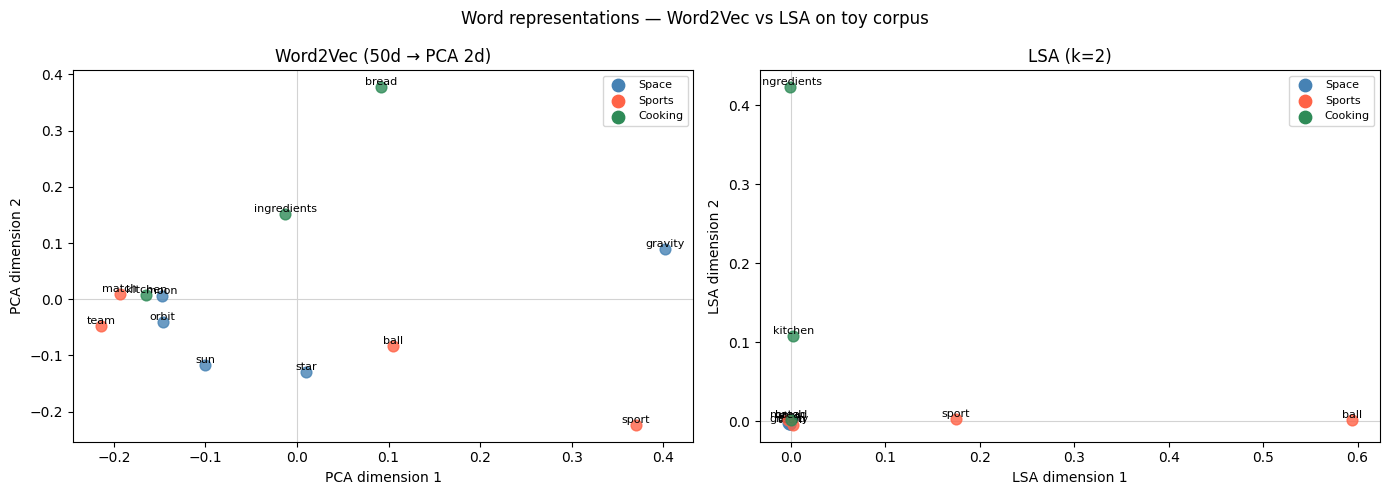

In [56]:
# Project 50-d vectors to 2D with PCA for visualisation
words_to_plot = [w for w in target_words if w in w2v.wv]
w2v_vecs = np.array([w2v.wv[w] for w in words_to_plot])

pca = PCA(n_components=2, random_state=42)
w2v_2d = pca.fit_transform(w2v_vecs)

word_to_topic = dict(zip(
    target_words,
    ["Space"]*6 + ["Sports"]*6 + ["Cooking"]*6
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Word2Vec plot ---
ax = axes[0]
for word, (x, y) in zip(words_to_plot, w2v_2d):
    color = topic_colors[word_to_topic[word]]
    ax.scatter(x, y, color=color, s=60, alpha=0.8, zorder=3)
    ax.annotate(word, (x, y), fontsize=8, ha='center', va='bottom')
for label, color in topic_colors.items():
    ax.scatter([], [], color=color, label=label, s=80)
ax.legend(fontsize=8)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.set_xlabel("PCA dimension 1")
ax.set_ylabel("PCA dimension 2")
ax.set_title("Word2Vec (50d → PCA 2d)")

# --- LSA word plot (repeated for side-by-side) ---
ax = axes[1]
for word, topic in zip(target_words, ["Space"]*6+["Sports"]*6+["Cooking"]*6):
    if word in vocab:
        idx = np.where(vocab == word)[0][0]
        x, y = X_words[idx]
        ax.scatter(x, y, color=topic_colors[topic], s=60, alpha=0.8, zorder=3)
        ax.annotate(word, (x, y), fontsize=8, ha='center', va='bottom')
for label, color in topic_colors.items():
    ax.scatter([], [], color=color, label=label, s=80)
ax.legend(fontsize=8)
ax.axhline(0, color='lightgray', lw=0.8)
ax.axvline(0, color='lightgray', lw=0.8)
ax.set_xlabel("LSA dimension 1")
ax.set_ylabel("LSA dimension 2")
ax.set_title("LSA (k=2)")

plt.suptitle("Word representations — Word2Vec vs LSA on toy corpus", fontsize=12)
plt.tight_layout()
plt.show()

> **Exercise 2.1** — The Word2Vec clusters look less clean than LSA on this small corpus. Why? What would happen with 10,000 sentences instead of 18?

> **Exercise 2.2** — Change `sg=0` (CBOW) or `window=1` vs `window=5`. What changes in the clustering? How does window size relate to the type of similarity captured?

---
## Part 3 — Comparison: LSA vs Word2Vec

### 3.1 — Side-by-side similarity table

In [57]:
def w2v_sim(w1, w2):
    if w1 in w2v.wv and w2 in w2v.wv:
        return float(w2v.wv.similarity(w1, w2))
    return None

all_pairs = [
    # Same-topic
    ("sun", "moon"),
    ("ball", "team"),
    ("cook", "recipe"),
    ("star", "orbit"),
    ("player", "goal"),
    ("kitchen", "ingredients"),
    # Cross-topic
    ("sun", "ball"),
    ("moon", "cook"),
    ("star", "goal"),  # 'star' is ambiguous!
    ("gravity", "recipe"),
]

print(f"{'Word pair':<30} {'LSA':>8} {'Word2Vec':>10}")
print("-" * 50)
print("--- Same-topic pairs ---")
for i, (w1, w2) in enumerate(all_pairs):
    if i == 6:
        print("--- Cross-topic pairs ---")
    ls = lsa_word_sim(w1, w2)
    ws = w2v_sim(w1, w2)
    ls_str = f"{ls:8.3f}" if ls is not None else "     N/A"
    ws_str = f"{ws:8.3f}" if ws is not None else "       N/A"
    print(f"  {w1} ↔ {w2:<22}{ls_str}{ws_str}")

Word pair                           LSA   Word2Vec
--------------------------------------------------
--- Same-topic pairs ---
  sun ↔ moon                     0.800   0.946
  ball ↔ team                     0.383   0.937
  cook ↔ recipe                     N/A       N/A
  star ↔ orbit                   -0.213   0.959
  player ↔ goal                       N/A       N/A
  kitchen ↔ ingredients              1.000   0.948
--- Cross-topic pairs ---
  sun ↔ ball                    -0.813   0.941
  moon ↔ cook                       N/A       N/A
  star ↔ goal                       N/A       N/A
  gravity ↔ recipe                     N/A       N/A


### 3.2 — Pre-trained GloVe embeddings

Training on 18 sentences is insufficient for Word2Vec to learn meaningful representations.
In practice, Word2Vec and GloVe are trained on **billions of tokens** (Wikipedia, Common Crawl).

Let's load pre-trained **GloVe** vectors (50d, trained on Wikipedia + Gigaword, ~400k vocabulary):

In [42]:
# Downloads ~66 MB on first run — cached afterwards
print("Loading pre-trained GloVe vectors (first run: ~66 MB download)...")
glove = gensim.downloader.load('glove-wiki-gigaword-50')
print(f"Loaded: {len(glove):,} words — {glove.vector_size}d vectors")

Loading pre-trained GloVe vectors (first run: ~66 MB download)...
Loaded: 400,000 words — 50d vectors


In [43]:
# Classic analogy: king − man + woman ≈ queen
def analogy(model, pos1, neg1, pos2, topn=4):
    result = model.most_similar(positive=[pos1, pos2], negative=[neg1], topn=topn)
    print(f"  {pos1} − {neg1} + {pos2}  →  {[w for w, _ in result]}")

print("Analogy tests with pre-trained GloVe (A − B + C ≈ ?)")
print()
analogy(glove, "king",   "man",     "woman")     # → queen
analogy(glove, "paris",  "france",  "italy")     # → rome
analogy(glove, "walk",   "walking", "swimming")  # → swim
analogy(glove, "better", "good",    "bad")       # → worse
analogy(glove, "doctor", "man",     "woman")     # gender bias

Analogy tests with pre-trained GloVe (A − B + C ≈ ?)

  king − man + woman  →  ['queen', 'throne', 'prince', 'daughter']
  paris − france + italy  →  ['rome', 'milan', 'turin', 'venice']
  walk − walking + swimming  →  ['pool', 'swim', 'indoor', 'rowing']
  better − good + bad  →  ['worse', 'too', 'unfortunately', 'because']
  doctor − man + woman  →  ['nurse', 'child', 'pregnant', 'mother']


In [44]:
# Three-way similarity comparison: LSA (toy) vs Word2Vec (toy) vs GloVe (large)
comparison_pairs = [
    ("sun",     "moon"),
    ("sun",     "ball"),
    ("star",    "planet"),
    ("star",    "goal"),
    ("cook",    "recipe"),
    ("cook",    "orbit"),
    ("player",  "athlete"),
    ("bread",   "flour"),
]

print(f"{'Word pair':<25} {'LSA (toy)':>11} {'W2V (toy)':>11} {'GloVe (large)':>14}")
print("-" * 63)
for w1, w2 in comparison_pairs:
    ls = lsa_word_sim(w1, w2)
    ws = w2v_sim(w1, w2)
    try:
        gs = glove.similarity(w1, w2)
    except KeyError:
        gs = None
    ls_str = f"{ls:9.3f}" if ls is not None else "        N/A"
    ws_str = f"{ws:9.3f}" if ws is not None else "        N/A"
    gs_str = f"{gs:9.3f}" if gs is not None else "           N/A"
    print(f"  {w1} ↔ {w2:<18}{ls_str}{ws_str}{gs_str}")

Word pair                   LSA (toy)   W2V (toy)  GloVe (large)
---------------------------------------------------------------
  sun ↔ moon                  0.800    0.946    0.654
  sun ↔ ball                 -0.813    0.941    0.347
  star ↔ planet                    N/A        N/A    0.476
  star ↔ goal                      N/A        N/A    0.439
  cook ↔ recipe                    N/A        N/A    0.620
  cook ↔ orbit                     N/A        N/A    0.109
  player ↔ athlete                   N/A        N/A    0.676
  bread ↔ flour                 1.000    0.995    0.818


> **Exercise 3.1** — For which pairs do LSA and GloVe agree? For which do they disagree most? What explains the disagreements?

> **Exercise 3.2** — Try analogy arithmetic with your toy LSA vectors (use `X_words` and `vocab`). Does it work? Why or why not?

> **Exercise 3.3** — The last analogy (`doctor − man + woman`) often returns a gender-biased result. What does this tell us about what Word2Vec / GloVe capture?

---
## Summary: LSA vs Word2Vec

| Property | LSA | Word2Vec |
|---|---|---|
| Method | SVD on count matrix | Skip-gram neural classifier |
| Training | Closed-form (fast) | Gradient descent (slower) |
| Data needed | Works on small corpora | Needs millions of tokens |
| Polysemy | One vector per word (poor) | One vector per word (poor) |
| Analogy structure | Weak | Strong at scale |
| Interpretability | Moderate (SVD components) | Low |
| Scales with corpus | Limited by matrix size | Scales with SGD |

**Both methods produce a single static vector per word** regardless of context.
This is a fundamental limitation — the word *bank* has one vector whether it refers to a riverbank or a financial institution.
**Contextualised embeddings** (ELMo, BERT, GPT) solve this by making representations context-dependent.
This is exactly what the Transformer architecture achieves — next lecture.

> **Final exercise** — In what scenario would you choose LSA over Word2Vec?  
> Think about: corpus size, compute budget, interpretability requirements, and domain-specific vocabulary.